# Mobile Price Classification


**Dataset:** Mobile Price Classification (Kaggle)  
**Task:** Supervised Learning  - Multi-class Classification  
**Goal:** Predict the price range of a mobile phone (0=Budget, 1=Low-Mid, 2=High-Mid, 3=Premium)  
based on its hardware specifications.

---


## Phase 1: Data Preparation

### 1.1  - Import Libraries

In [19]:
# Standard libraries for data manipulation and visualization
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Scikit-learn: preprocessing, models, evaluation
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Plot styling
sns.set_theme(style='whitegrid', palette='mako')
plt.rcParams['figure.dpi'] = 120

print('All libraries imported successfully')

All libraries imported successfully


### 1.2  - Load the Datasets

We have two CSV files:
- **train.csv**  - labeled data used for training and validation (2000 rows, includes `price_range`)
- **test.csv**  - unlabeled data for final prediction submission (1000 rows, no `price_range`)

In [20]:
# Load training data
train = pd.read_csv('/content/sample_data/train.csv')

# Load test data
test = pd.read_csv('/content/sample_data/test.csv')

print(f'Training set shape : {train.shape}  {train.shape[0]} phones, {train.shape[1]} columns')
print(f'Test set shape     : {test.shape}  {test.shape[0]} phones, {test.shape[1]} columns')
print()
print('Training columns:', list(train.columns))

Training set shape : (2000, 21)  2000 phones, 21 columns
Test set shape     : (1000, 21)  1000 phones, 21 columns

Training columns: ['battery_power', 'blue', 'clock_speed', 'dual_sim', 'fc', 'four_g', 'int_memory', 'm_dep', 'mobile_wt', 'n_cores', 'pc', 'px_height', 'px_width', 'ram', 'sc_h', 'sc_w', 'talk_time', 'three_g', 'touch_screen', 'wifi', 'price_range']


In [21]:
# Preview the first 5 rows of the training set
train.head()

,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,n_cores,...,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi,price_range
0,842,0,2.2,0,1,0,7,0.6,188,2,...,20,756,2549,9,7,19,0,0,1,1
1,1021,1,0.5,1,0,1,53,0.7,136,3,...,905,1988,2631,17,3,7,1,1,0,2
2,563,1,0.5,1,2,1,41,0.9,145,5,...,1263,1716,2603,11,2,9,1,1,0,2
3,615,1,2.5,0,0,0,10,0.8,131,6,...,1216,1786,2769,16,8,11,1,0,0,2
4,1821,1,1.2,0,13,1,44,0.6,141,2,...,1208,1212,1411,8,2,15,1,1,0,1


### 1.3  - Data Types and Basic Info

In [22]:
# Check data types and non-null counts
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   battery_power  2000 non-null   int64  
 1   blue           2000 non-null   int64  
 2   clock_speed    2000 non-null   float64
 3   dual_sim       2000 non-null   int64  
 4   fc             2000 non-null   int64  
 5   four_g         2000 non-null   int64  
 6   int_memory     2000 non-null   int64  
 7   m_dep          2000 non-null   float64
 8   mobile_wt      2000 non-null   int64  
 9   n_cores        2000 non-null   int64  
 10  pc             2000 non-null   int64  
 11  px_height      2000 non-null   int64  
 12  px_width       2000 non-null   int64  
 13  ram            2000 non-null   int64  
 14  sc_h           2000 non-null   int64  
 15  sc_w           2000 non-null   int64  
 16  talk_time      2000 non-null   int64  
 17  three_g        2000 non-null   int64  
 18  touch_sc

### 1.4  - Missing Value Check

Missing values can cause models to fail or produce biased results.
We check every column before proceeding.

In [23]:
# Count missing values in each column
print(train.isnull().sum())
print(test.isnull().sum())
print('Missing values in training set:')
print('None  - dataset is clean!')
print('\nMissing values in test set:')
print(' None  - dataset is clean!')

battery_power    0
blue             0
clock_speed      0
dual_sim         0
fc               0
four_g           0
int_memory       0
m_dep            0
mobile_wt        0
n_cores          0
pc               0
px_height        0
px_width         0
ram              0
sc_h             0
sc_w             0
talk_time        0
three_g          0
touch_screen     0
wifi             0
price_range      0
dtype: int64
id               0
battery_power    0
blue             0
clock_speed      0
dual_sim         0
fc               0
four_g           0
int_memory       0
m_dep            0
mobile_wt        0
n_cores          0
pc               0
px_height        0
px_width         0
ram              0
sc_h             0
sc_w             0
talk_time        0
three_g          0
touch_screen     0
wifi             0
dtype: int64
Missing values in training set:
None  - dataset is clean!

Missing values in test set:
 None  - dataset is clean!


### 1.5  - Target Variable: Price Range Distribution

The target variable `price_range` has 4 classes:
- **0**   Budget
- **1**   Low-Mid
- **2**   High-Mid  
- **3**   Premium

A balanced distribution means our model won't be biased toward any single class.

Price range distribution:
price_range
0    500
1    500
2    500
3    500
Name: count, dtype: int64


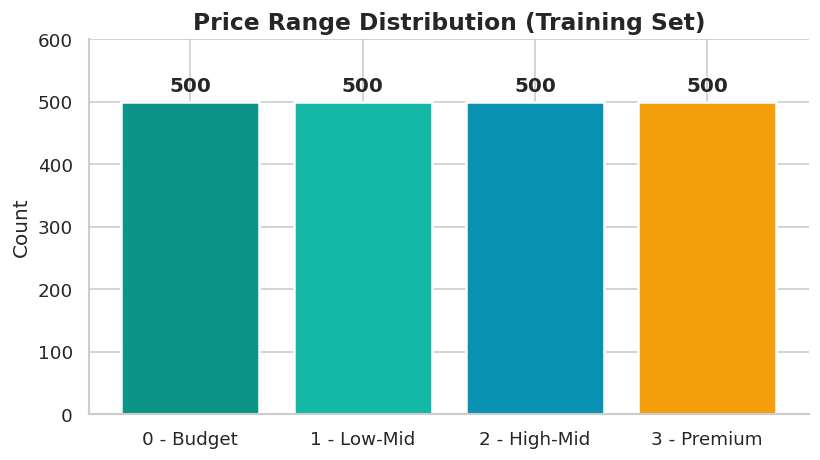


 Dataset is perfectly balanced: 500 samples per class


In [24]:
# Count samples per price class
price_counts = train['price_range'].value_counts().sort_index() # 0 1 2 3
print('Price range distribution:')
print(price_counts)

# Visualize
fig, ax = plt.subplots(figsize=(7, 4))
colors = ['#0D9488', '#14B8A6', '#0891B2', '#F59E0B']
bars = ax.bar(['0 - Budget', '1 - Low-Mid', '2 - High-Mid', '3 - Premium'],
              price_counts.values, color=colors, edgecolor='white', linewidth=1.5)
ax.bar_label(bars, fmt='%d', padding=4, fontweight='bold')
ax.set_title('Price Range Distribution (Training Set)', fontsize=14, fontweight='bold')
ax.set_ylabel('Count')
ax.set_ylim(0, 600)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

print(f'\n Dataset is perfectly balanced: {price_counts.iloc[0]} samples per class')

### 1.6  - Outlier Analysis

We use boxplots to visualize the spread of numerical features and identify any extreme outliers.

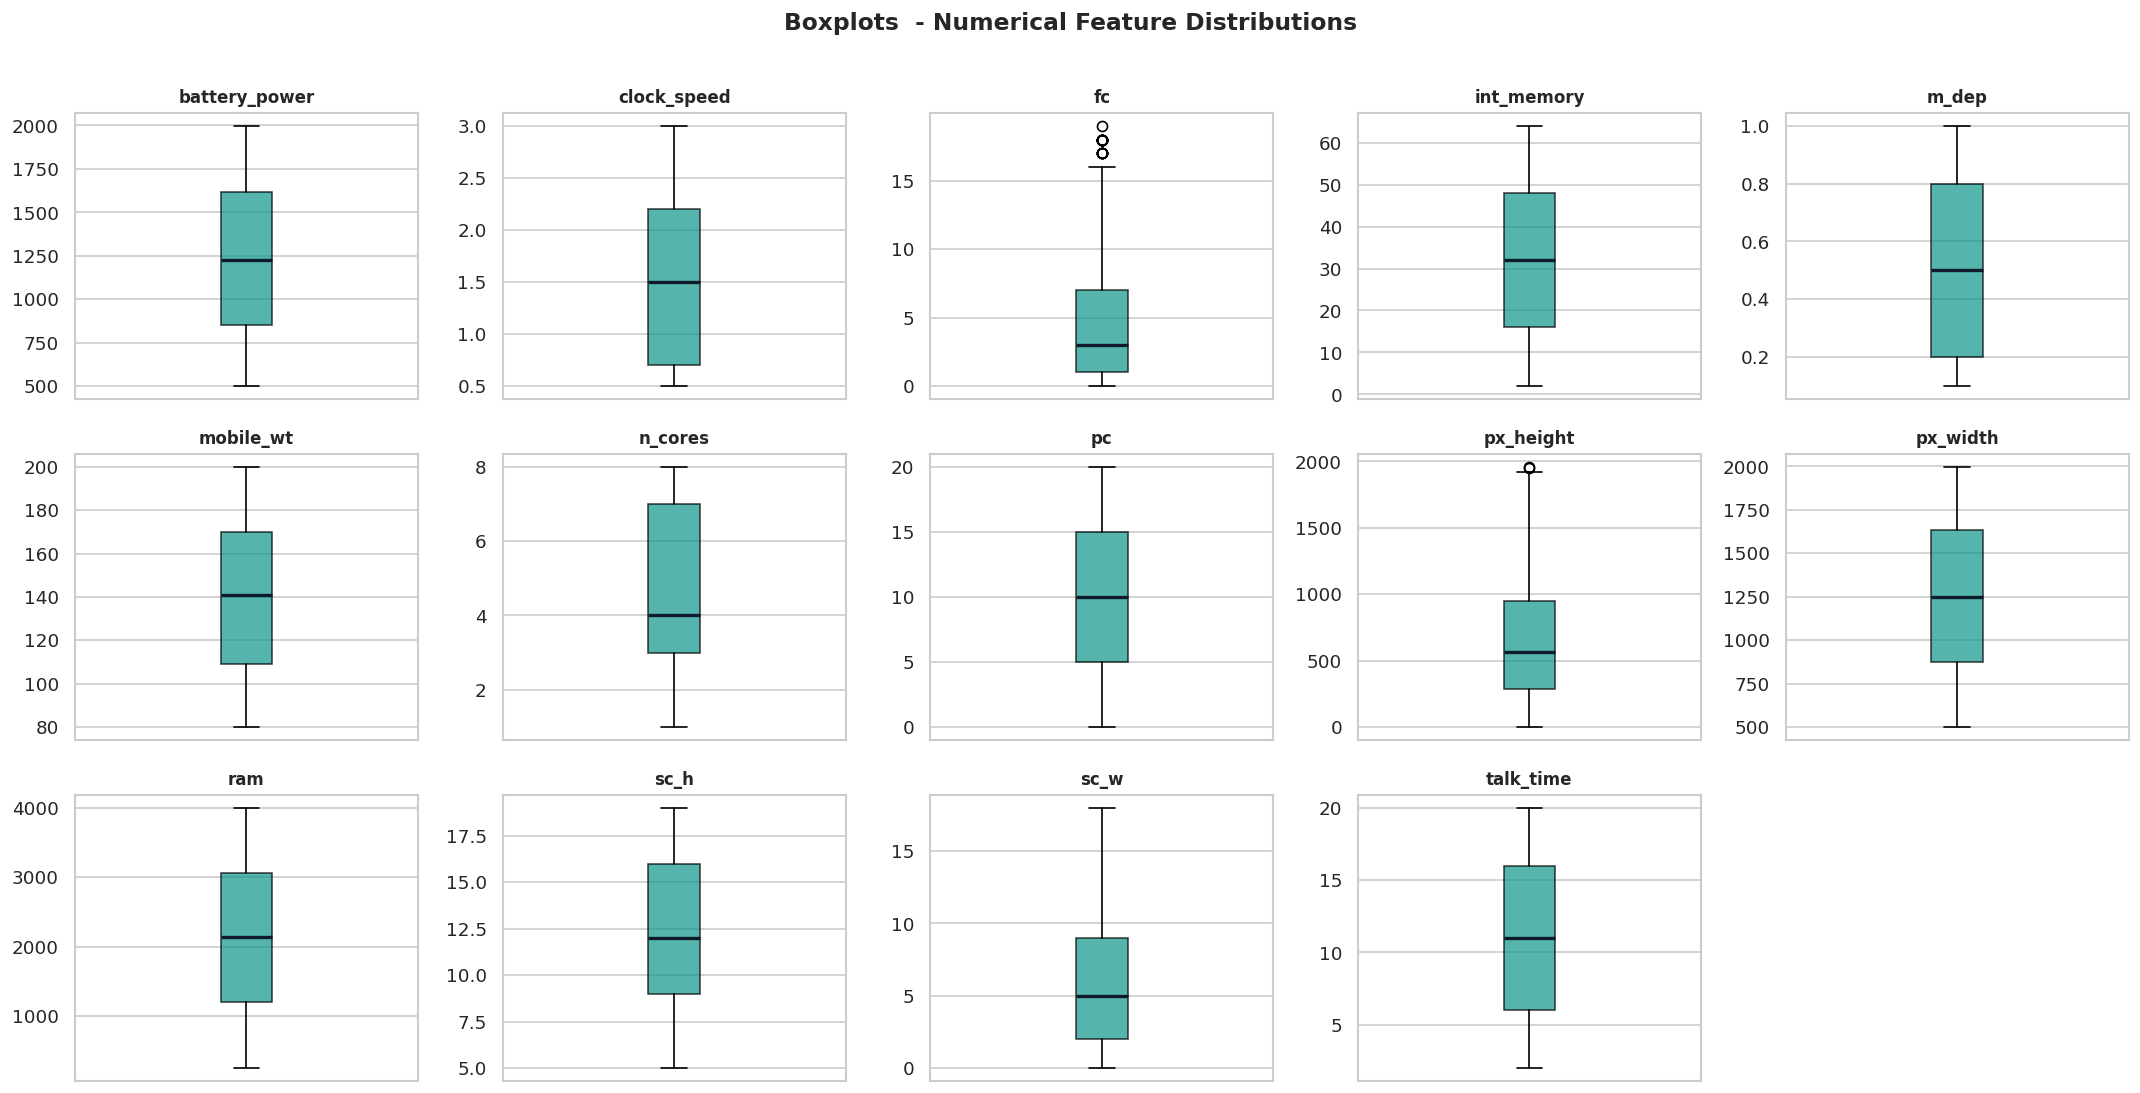

Observation: No extreme outliers requiring removal. Distributions look reasonable.


In [25]:
# Select continuous/numerical features (exclude binary and target)
num_cols = ['battery_power', 'clock_speed', 'fc', 'int_memory', 'm_dep',
            'mobile_wt', 'n_cores', 'pc', 'px_height', 'px_width',
            'ram', 'sc_h', 'sc_w', 'talk_time']

fig, axes = plt.subplots(3, 5, figsize=(18, 9))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    axes[i].boxplot(train[col], patch_artist=True,
                    boxprops=dict(facecolor='#0D9488', alpha=0.7),
                    medianprops=dict(color='#0D1B2A', linewidth=2))
    axes[i].set_title(col, fontsize=10, fontweight='bold')
    axes[i].set_xticks([])

# Hide the unused subplot
for j in range(len(num_cols), len(axes)):
    axes[j].set_visible(False)

fig.suptitle('Boxplots  - Numerical Feature Distributions', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

print('Observation: No extreme outliers requiring removal. Distributions look reasonable.')

### 1.7  - Prepare Features and Labels

In [26]:
# Separate features from label
X = train.drop('price_range', axis=1)   # Feature matrix
y = train['price_range']                 # Target

# Test set: drop id column (not a feature)
X_test_final = test.drop('id', axis=1)

print(f'X shape          : {X.shape}')           # (2000, 22)
print(f'y shape          : {y.shape}')           # (2000,)
print(f'X_test_final shape: {X_test_final.shape}') # (1000, 22)
print(f'\nFeatures used: {list(X.columns)}')

X shape          : (2000, 20)
y shape          : (2000,)
X_test_final shape: (1000, 20)

Features used: ['battery_power', 'blue', 'clock_speed', 'dual_sim', 'fc', 'four_g', 'int_memory', 'm_dep', 'mobile_wt', 'n_cores', 'pc', 'px_height', 'px_width', 'ram', 'sc_h', 'sc_w', 'talk_time', 'three_g', 'touch_screen', 'wifi']


---
## Phase 2: Modeling and Evaluation

We split the data into **80% training / 20% validation** (stratified to preserve class balance),  
then train and evaluate **3 classification algorithms** on the same split.

### Algorithms:
1. **Logistic Regression**  - linear probabilistic classifier  
2. **Random Forest**  - ensemble of decision trees  
3. **Gradient Boosting**  - sequential ensemble, typically stronger than RF

### 2.1  - Train / Validation Split

In [27]:
# 80/20 split  - stratified to keep class balance in both sets
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Training samples  : {X_train.shape[0]}  ({X_train.shape[0]/len(X)*100:.0f}%)')
print(f'Validation samples: {X_val.shape[0]}   ({X_val.shape[0]/len(X)*100:.0f}%)')
print()
print('Class distribution in validation set:')
print(y_val.value_counts().sort_index())

Training samples  : 1600  (80%)
Validation samples: 400   (20%)

Class distribution in validation set:
price_range
0    100
1    100
2    100
3    100
Name: count, dtype: int64


### 2.2  - Algorithm 1: Logistic Regression

A linear probabilistic classifier. Despite its simplicity, it works well when features have a near-linear relationship with the target.

- `C=1.0`   regularization strength
- `max_iter=1000`   increase iterations to ensure convergence

In [28]:
# Train Logistic Regression
lr = LogisticRegression(C=1.0, max_iter=1000, random_state=42)
lr.fit(X_train, y_train)
lr_pred = lr.predict(X_val)
lr_acc  = accuracy_score(y_val, lr_pred)

print('Logistic Regression Results:')
print(f'  Validation Accuracy: {lr_acc:.4f} ({lr_acc*100:.2f}%)')
print()
print('Classification Report:')
print(classification_report(y_val, lr_pred,
      target_names=['0-Budget', '1-LowMid', '2-HighMid', '3-Premium']))

Logistic Regression Results:
  Validation Accuracy: 0.6750 (67.50%)

Classification Report:
              precision    recall  f1-score   support

    0-Budget       0.91      0.85      0.88       100
    1-LowMid       0.61      0.62      0.61       100
   2-HighMid       0.49      0.55      0.52       100
   3-Premium       0.73      0.68      0.70       100

    accuracy                           0.68       400
   macro avg       0.69      0.68      0.68       400
weighted avg       0.69      0.68      0.68       400



/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


### 2.3  - Algorithm 2: Random Forest

An ensemble of decision trees trained on random subsets of data and features.
Reduces overfitting compared to a single decision tree.

- `n_estimators=200`   200 trees in the forest
- `n_jobs=-1`   use all CPU cores for speed

In [29]:
# Train Random Forest
rf = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_val)
rf_acc  = accuracy_score(y_val, rf_pred)

print('Random Forest Results:')
print(f'  Validation Accuracy: {rf_acc:.4f} ({rf_acc*100:.2f}%)')
print()
print('Classification Report:')
print(classification_report(y_val, rf_pred,
      target_names=['0-Budget', '1-LowMid', '2-HighMid', '3-Premium']))

Random Forest Results:
  Validation Accuracy: 0.8775 (87.75%)

Classification Report:
              precision    recall  f1-score   support

    0-Budget       0.94      0.95      0.95       100
    1-LowMid       0.81      0.84      0.82       100
   2-HighMid       0.82      0.79      0.81       100
   3-Premium       0.94      0.93      0.93       100

    accuracy                           0.88       400
   macro avg       0.88      0.88      0.88       400
weighted avg       0.88      0.88      0.88       400



### 2.4  - Algorithm 3: Gradient Boosting

Builds trees sequentially  - each tree corrects the errors of the previous one.
Generally more accurate than Random Forest but slower to train.

- `n_estimators=200`   number of boosting stages
- `learning_rate=0.1`   how much each tree contributes
- `max_depth=4`   controls tree complexity

In [12]:
# Train Gradient Boosting
gb = GradientBoostingClassifier(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=4,
    random_state=42
)
gb.fit(X_train, y_train)
gb_pred = gb.predict(X_val)
gb_acc  = accuracy_score(y_val, gb_pred)

print('Gradient Boosting Results:')
print(f'  Validation Accuracy: {gb_acc:.4f} ({gb_acc*100:.2f}%)')
print()
print('Classification Report:')
print(classification_report(y_val, gb_pred,
      target_names=['0-Budget', '1-LowMid', '2-HighMid', '3-Premium']))

Gradient Boosting Results:
  Validation Accuracy: 0.9300 (93.00%)

Classification Report:
              precision    recall  f1-score   support

    0-Budget       0.96      0.99      0.98       100
    1-LowMid       0.92      0.92      0.92       100
   2-HighMid       0.89      0.88      0.88       100
   3-Premium       0.95      0.93      0.94       100

    accuracy                           0.93       400
   macro avg       0.93      0.93      0.93       400
weighted avg       0.93      0.93      0.93       400



### 2.5  - Model Comparison & Best Model Selection

In [13]:
# Build comparison table
results = pd.DataFrame({
    'Model'               : ['Logistic Regression', 'Random Forest', 'Gradient Boosting'],
    'Validation Accuracy' : [lr_acc, rf_acc, gb_acc],
}).sort_values('Validation Accuracy', ascending=False).reset_index(drop=True)

results.index += 1

# Identify best model
best_model_name = results.iloc[0]['Model']
best_accuracy   = results.iloc[0]['Validation Accuracy']

# Format for display
results_display = results.copy()
results_display['Validation Accuracy'] = results_display['Validation Accuracy'].map(lambda x: f'{x*100:.2f}%')
results_display['Rank'] = ['BEST', ' 2nd', '3rd']
print('       MODEL COMPARISON (sorted by accuracy)')
print(results_display[['Rank', 'Model', 'Validation Accuracy']].to_string(index=False))
print(f'\n BEST MODEL: {best_model_name}')
print(f'   Validation Accuracy: {best_accuracy*100:.2f}%')

       MODEL COMPARISON (sorted by accuracy)
Rank               Model Validation Accuracy
BEST   Gradient Boosting              93.00%
 2nd       Random Forest              87.75%
 3rd Logistic Regression              67.50%

 BEST MODEL: Gradient Boosting
   Validation Accuracy: 93.00%


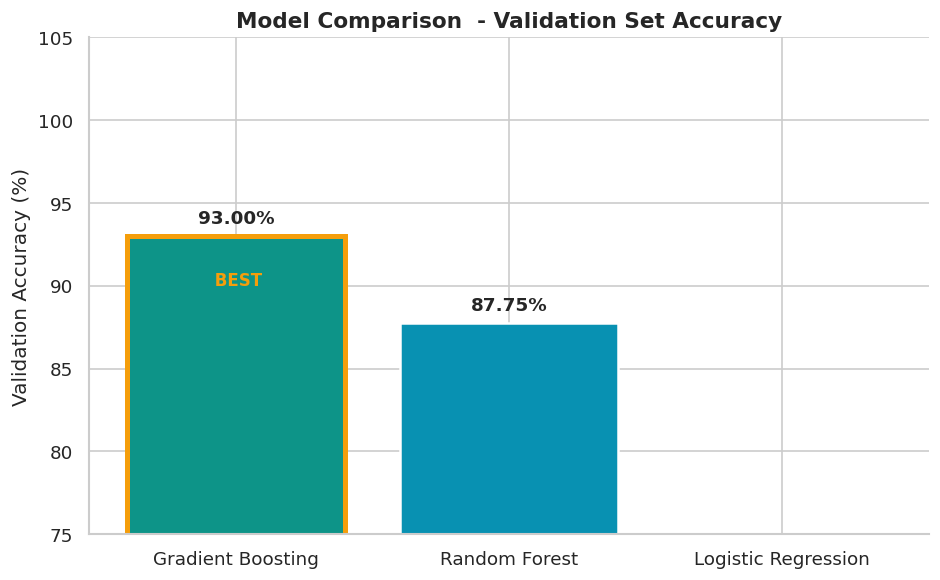


]Best Model: Gradient Boosting with 93.00% accuracy


In [14]:
# Visualize model comparison
models_sorted = results['Model'].tolist()
accs_sorted   = (results['Validation Accuracy'] * 100).tolist()
bar_colors    = ['#0D9488', '#0891B2', '#94A3B8']  # best = brightest

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(models_sorted, accs_sorted, color=bar_colors,
              edgecolor='white', linewidth=1.5)
ax.bar_label(bars, labels=[f'{a:.2f}%' for a in accs_sorted],
             padding=5, fontweight='bold', fontsize=11)

# Mark the best model
bars[0].set_edgecolor('#F59E0B')
bars[0].set_linewidth(3)
ax.text(0, accs_sorted[0] - 3, ' BEST', ha='center', fontsize=10,
        color='#F59E0B', fontweight='bold')

ax.set_ylim(75, 105)
ax.set_ylabel('Validation Accuracy (%)', fontsize=12)
ax.set_title('Model Comparison  - Validation Set Accuracy', fontsize=13, fontweight='bold')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

print(f'\n]Best Model: {best_model_name} with {best_accuracy*100:.2f}% accuracy')

### 2.6  - Best Model: Confusion Matrix

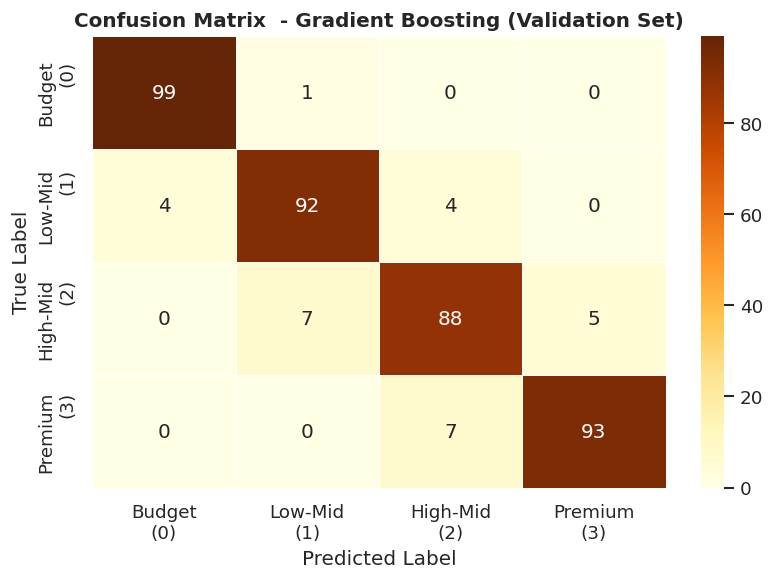

Validation Accuracy: 93.00%
Observation: Most misclassifications occur between adjacent classes (0↔1 or 2↔3), which is expected.


In [15]:
# Select predictions from the best model
best_models = {
    'Logistic Regression': lr_pred,
    'Random Forest'      : rf_pred,
    'Gradient Boosting'  : gb_pred
}
best_pred = best_models[best_model_name]

# Confusion Matrix
cm = confusion_matrix(y_val, best_pred)
labels = ['Budget\n(0)', 'Low-Mid\n(1)', 'High-Mid\n(2)', 'Premium\n(3)'] # class

fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='YlOrBr',
            xticklabels=labels, yticklabels=labels,
            linewidths=0.5, linecolor='white', ax=ax)
ax.set_xlabel('Predicted Label', fontsize=12)
ax.set_ylabel('True Label', fontsize=12)
ax.set_title(f'Confusion Matrix  - {best_model_name} (Validation Set)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'Validation Accuracy: {best_accuracy*100:.2f}%')
print('Observation: Most misclassifications occur between adjacent classes (0↔1 or 2↔3), which is expected.')

---
## Phase 3: Visualization and Insights

### 3.1  - Correlation with Price Range

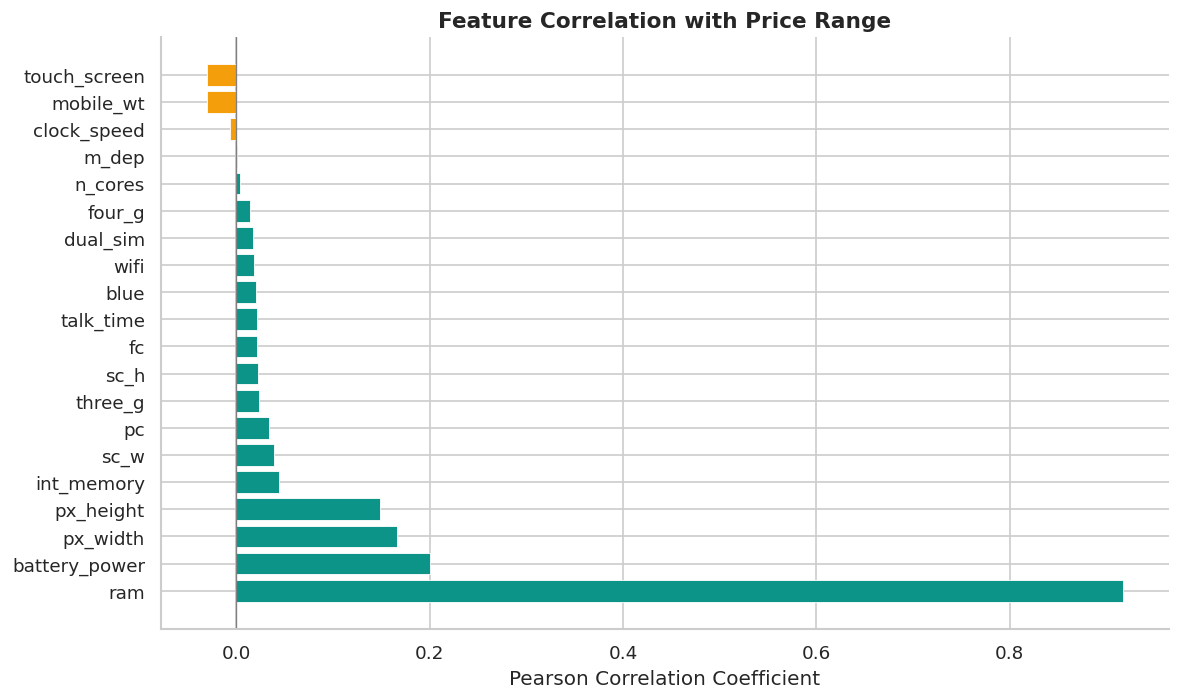

Top 5 most correlated features:
ram              0.917
battery_power    0.201
px_width         0.166
px_height        0.149
int_memory       0.044
Name: price_range, dtype: float64

 Key finding: RAM has an extremely high correlation of 0.917  - by far the strongest predictor.


In [16]:
# Pearson correlation of each feature with the target
corr = train.corr()['price_range'].drop('price_range').sort_values(ascending=False)

# Color bars: positive = teal, negative = amber
bar_colors = ['#0D9488' if v >= 0 else '#F59E0B' for v in corr.values]

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(corr.index, corr.values, color=bar_colors, edgecolor='white', linewidth=0.5)
ax.axvline(x=0, color='gray', linewidth=0.8)
ax.set_xlabel('Pearson Correlation Coefficient', fontsize=12)
ax.set_title('Feature Correlation with Price Range', fontsize=13, fontweight='bold')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

print('Top 5 most correlated features:')
print(corr.head().round(3))
print('\n Key finding: RAM has an extremely high correlation of 0.917  - by far the strongest predictor.')

### 3.2  - Random Forest Feature Importance

/tmp/ipykernel_32267/2321668543.py:14: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(importances.index, rotation=30, ha='right')


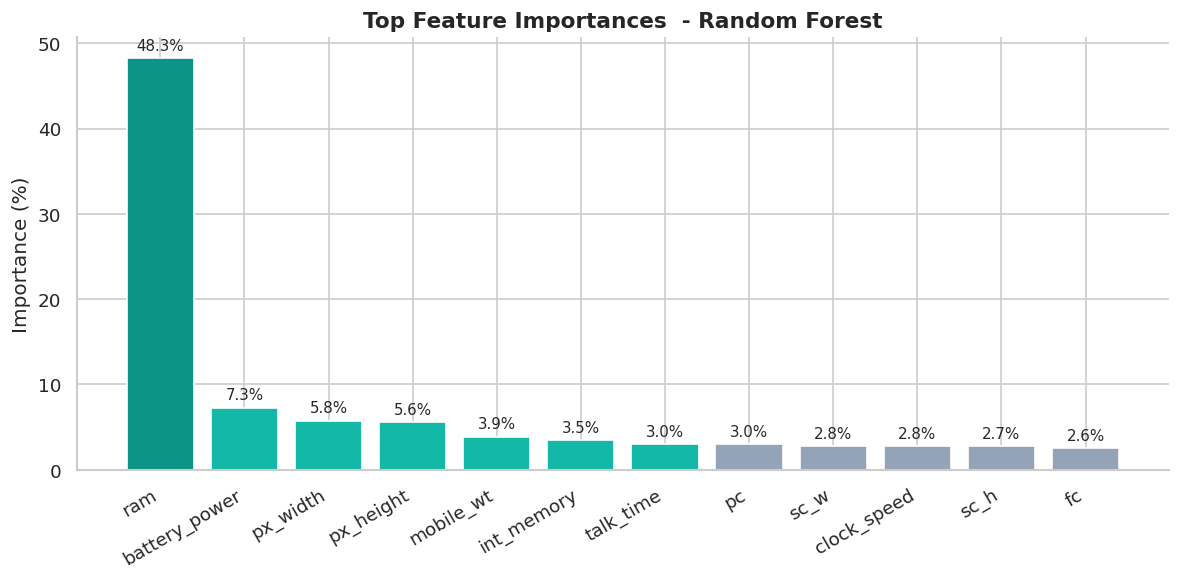

RAM accounts for 48.3% of the model's decision power


In [17]:
# Use the already-trained Random Forest model
importances = pd.Series(rf.feature_importances_, index=X.columns)
importances = importances.sort_values(ascending=False).head(12)

fig, ax = plt.subplots(figsize=(10, 5))
bar_clrs = ['#0D9488' if i == 0 else '#14B8A6' if importances.values[i] > 0.03
            else '#94A3B8' for i in range(len(importances))]
bars = ax.bar(importances.index, importances.values * 100, color=bar_clrs,
              edgecolor='white', linewidth=1)
ax.bar_label(bars, labels=[f'{v:.1f}%' for v in importances.values * 100],
             padding=3, fontsize=9)
ax.set_ylabel('Importance (%)', fontsize=12)
ax.set_title('Top Feature Importances  - Random Forest', fontsize=13, fontweight='bold')
ax.set_xticklabels(importances.index, rotation=30, ha='right')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

print(f'RAM accounts for {importances["ram"]*100:.1f}% of the model\'s decision power')

### 3.4  - Correlation Heatmap

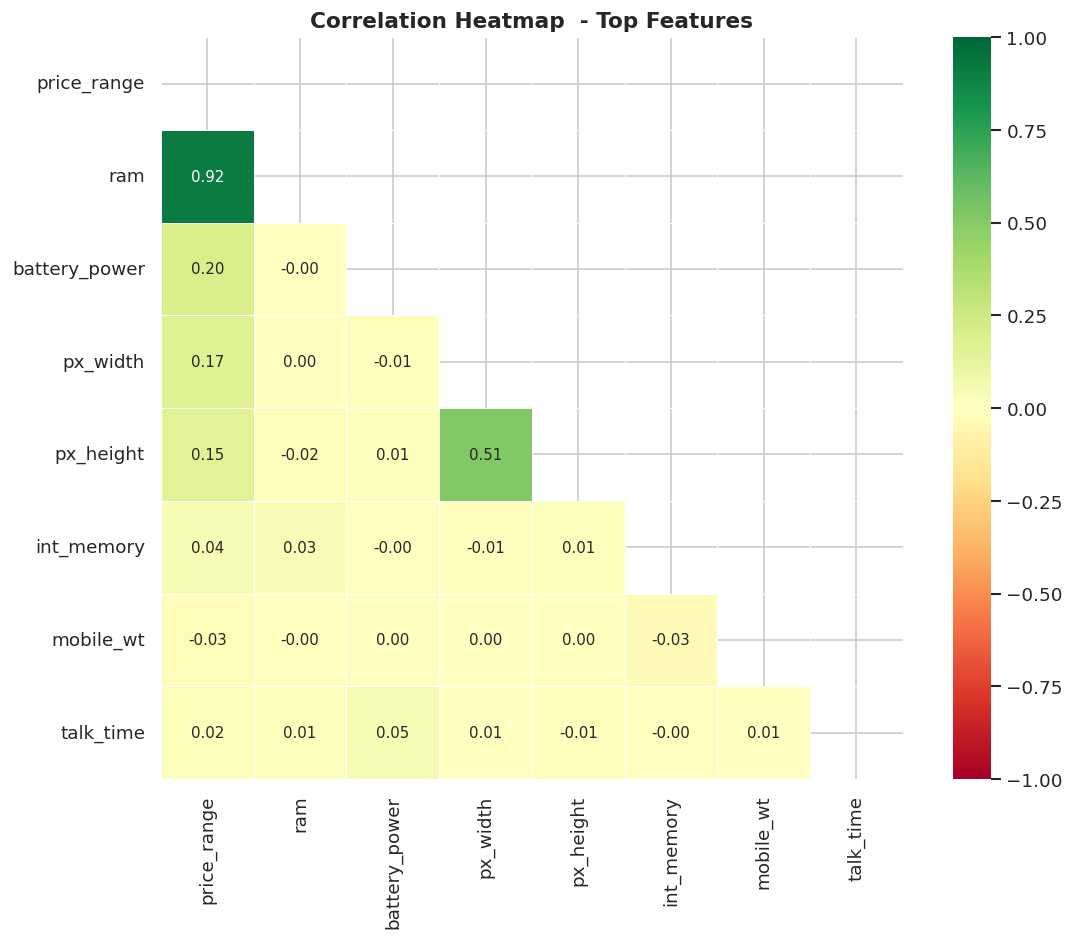

In [18]:
# Select top features for heatmap
top_feats = ['price_range', 'ram', 'battery_power', 'px_width', 'px_height',
             'int_memory', 'mobile_wt', 'talk_time']

fig, ax = plt.subplots(figsize=(10, 8))
corr_matrix = train[top_feats].corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))   # Show lower triangle only

sns.heatmap(
    corr_matrix, mask=mask, annot=True, fmt='.2f',
    cmap='RdYlGn', center=0, vmin=-1, vmax=1,
    linewidths=0.5, square=True, ax=ax,
    annot_kws={'size': 9}
)
ax.set_title('Correlation Heatmap  - Top Features', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## Summary of Findings

| Aspect | Finding |
|---|---|
| **Evaluation Method** | 80/20 Train-Validation Split (stratified) |
| **Best Model** | Gradient Boosting |
| **Key Feature** | RAM  - 0.917 correlation with price range |
| **Data Quality** | Zero missing values, perfectly balanced classes |
| **Key Insight** | The relationship between specs and price is near-linear after scaling |
| **Recommendation** | Focus on RAM and battery when pricing phones |